# Cluster-First STGNN — Analysis Notebook

This notebook analyses the full cluster-first pipeline after `src/train.py`
has been run.  It is structured in five sections:

| Section | What it covers |
|---------|----------------|
| 0 | Cluster visualization: Lyon map, summary table, affinity heatmap |
| 1 | Coarsened graph: K-node topology, cluster signals, conservation check |
| 2 | Training results: loss curves for K ∈ {5, 10, 20}, sweep table |
| 3 | Forecast quality: predicted vs actual, error distributions, baselines |
| 4 | UPF assignment: assignment map, timeline, energy comparison |
| 5 | Comparison with original BS-level STGNN |

**Prerequisites:** run from the repository root after `python -m src.train`.

**K to inspect (change to match your trained K):**

In [5]:
import sys
sys.path.insert(0, '..')  # repo root

import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np
import pandas as pd
import torch
import yaml

# K to inspect — change to match your best trained checkpoint
K_INSPECT = 10

with open('../config.yaml') as f:
    cfg = yaml.safe_load(f)

REPO_ROOT    = Path('..')
GRAPHS_DIR   = REPO_ROOT / cfg['paths']['graphs_dir']
OUTPUT_DIR   = REPO_ROOT / cfg['paths']['output_dir'] / f'K{K_INSPECT}'
CKPT_DIR     = REPO_ROOT / cfg['paths']['checkpoints_dir'] / f'K{K_INSPECT}'
RESULTS_DIR  = REPO_ROOT / cfg['paths']['results_dir']
FIGURES_DIR  = REPO_ROOT / cfg['paths']['figures_dir']

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print(f'Config loaded. Inspecting K={K_INSPECT}')
print(f'Output dir: {OUTPUT_DIR}')

Config loaded. Inspecting K=10
Output dir: ..\data\cluster_first\K10


---
## Section 0 — Cluster Visualization

Where did each gNodeB land? We plot the Lyon map coloured by cluster_id,
summarise each cluster's traffic characteristics, and inspect the affinity
matrix to see which BSs the composite kernel considered similar.

In [6]:
# Load cluster assignments and BS locations
assignments = pd.read_parquet(OUTPUT_DIR / 'cluster_assignments.parquet')
bs_locs     = pd.read_parquet(GRAPHS_DIR / 'bs_locations.parquet')
bs_locs['site_id'] = bs_locs['site_id'].astype(str)
assignments['site_id'] = assignments['site_id'].astype(str)

df_map = assignments.merge(bs_locs, on='site_id', how='left')
print(f'Loaded {len(df_map)} BS assignments across {K_INSPECT} clusters')
print(df_map.groupby('cluster_id').size().rename('n_members').to_frame())

Loaded 965 BS assignments across 10 clusters
            n_members
cluster_id           
0                  42
1                  79
2                  98
3                 158
4                  80
5                  55
6                  60
7                  36
8                 297
9                  60


C:\Users\Shima\AppData\Local\Temp\ipykernel_8632\2013094407.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', K_INSPECT)


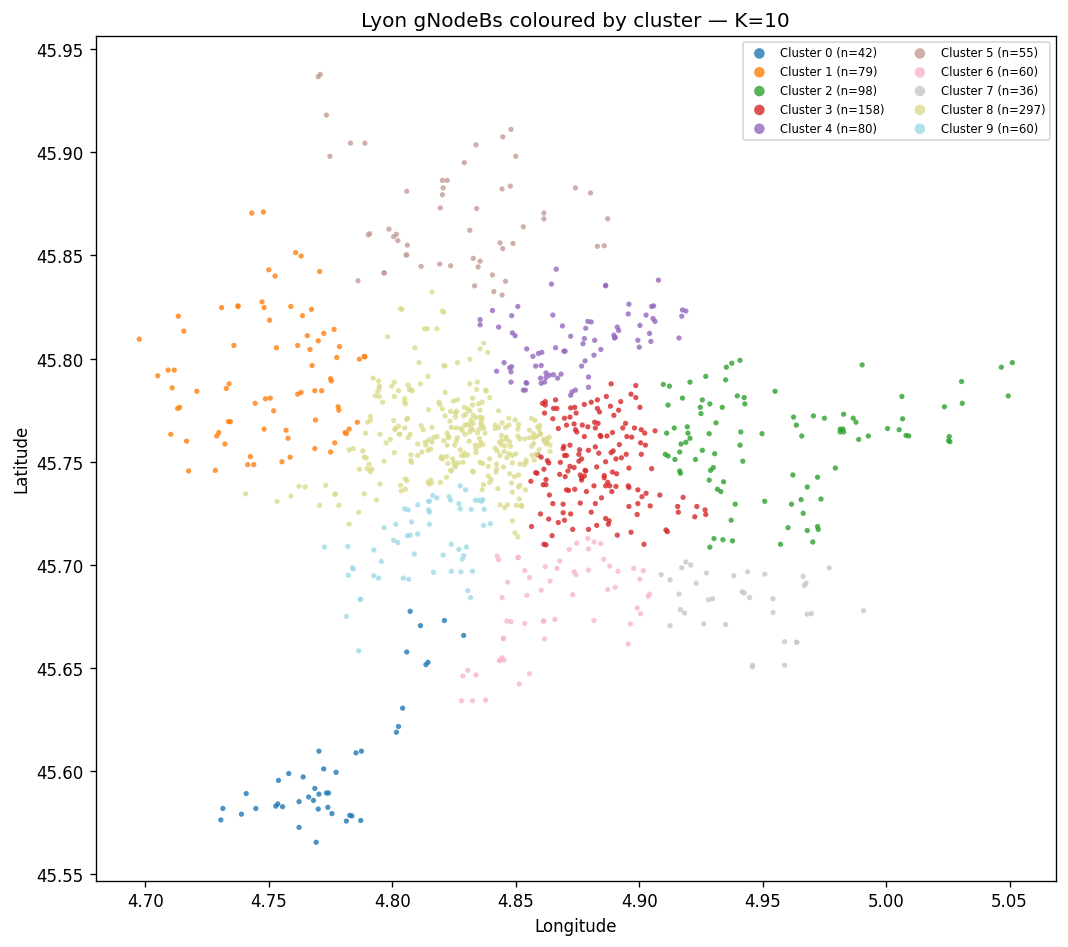

In [7]:
# ---- Lyon spatial map: BSs coloured by cluster_id ----
cmap = plt.cm.get_cmap('tab20', K_INSPECT)

fig, ax = plt.subplots(figsize=(9, 8))
for k in range(K_INSPECT):
    sub = df_map[df_map['cluster_id'] == k]
    ax.scatter(sub['lon'], sub['lat'], s=10, color=cmap(k),
               alpha=0.8, label=f'Cluster {k} (n={len(sub)})', edgecolors='none')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Lyon gNodeBs coloured by cluster — K={K_INSPECT}')
ax.legend(loc='upper right', fontsize=7, ncol=2, markerscale=2)
plt.tight_layout()
plt.show()

In [13]:
# ---- Cluster summary table ----
# Load BS stats from the training artefacts if available
# (they are computed inside train.py; we reconstruct a lightweight version here)
cluster_series = np.load(OUTPUT_DIR / 'cluster_series.npy')  # (K, T_total)

summary_rows = []
for k in range(K_INSPECT):
    sig = cluster_series[k]
    n_members = int((assignments['cluster_id'] == k).sum())
    summary_rows.append({
        'cluster_id':   k,
        'n_members':    n_members,
        'mean_signal':  float(np.mean(sig)),
        'peak_signal':  float(np.percentile(sig, 95)),
        'std_signal':   float(np.std(sig)),
        'cv':           float(np.std(sig) / (np.mean(sig) + 1e-8)),
    })

summary_df = pd.DataFrame(summary_rows).set_index('cluster_id')
display(summary_df.round(4))

,n_members,mean_signal,peak_signal,std_signal,cv
cluster_id,,,,,
0,42,0.2234,0.4419,0.1279,0.5726
1,79,0.5595,1.1409,0.3386,0.6053
2,98,0.9555,1.8103,0.5158,0.5398
3,158,1.8877,3.6107,1.0202,0.5404
4,80,0.7187,1.4105,0.4073,0.5667
5,55,0.3961,0.8108,0.2402,0.6064
6,60,0.3944,0.7409,0.2118,0.5371
7,36,0.3033,0.6084,0.1776,0.5856
8,297,3.3193,6.3259,1.8090,0.5450


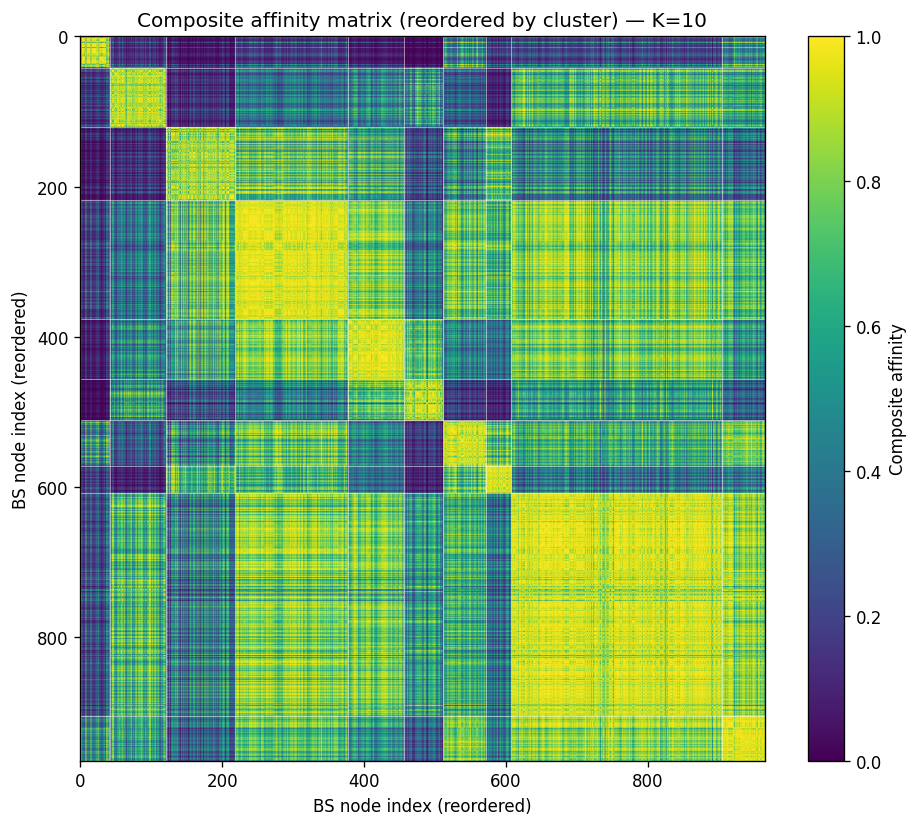

In [9]:
# ---- Affinity matrix heatmap (reordered by cluster_id) ----
A = np.load(OUTPUT_DIR / 'affinity_matrix.npy')  # (N, N)

# Reorder rows/cols by cluster membership
node_index = pd.read_parquet(GRAPHS_DIR / 'node_index.parquet')
node_index['site_id'] = node_index['site_id'].astype(str)
node_with_cluster = node_index.merge(assignments, on='site_id', how='left')
order = node_with_cluster.sort_values(['cluster_id', 'node_idx'])['node_idx'].values
A_reordered = A[np.ix_(order, order)]

# Boundaries for cluster blocks
cluster_sizes = node_with_cluster.sort_values('cluster_id').groupby('cluster_id').size().values
boundaries    = np.cumsum(cluster_sizes)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(A_reordered, cmap='viridis', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Composite affinity')
for b in boundaries[:-1]:
    ax.axhline(b - 0.5, color='white', linewidth=0.5, alpha=0.6)
    ax.axvline(b - 0.5, color='white', linewidth=0.5, alpha=0.6)
ax.set_title(f'Composite affinity matrix (reordered by cluster) — K={K_INSPECT}')
ax.set_xlabel('BS node index (reordered)')
ax.set_ylabel('BS node index (reordered)')
plt.tight_layout()
plt.show()

---
## Section 1 — Coarsened Graph Inspection

The K-node coarsened graph is the topology that ClusterSTGNN operates on.
We visualise it using networkx, inspect the full 77-day cluster signals,
and verify that coarsening conserves total traffic.

Coarse graph: 10 nodes, 36 directed edges


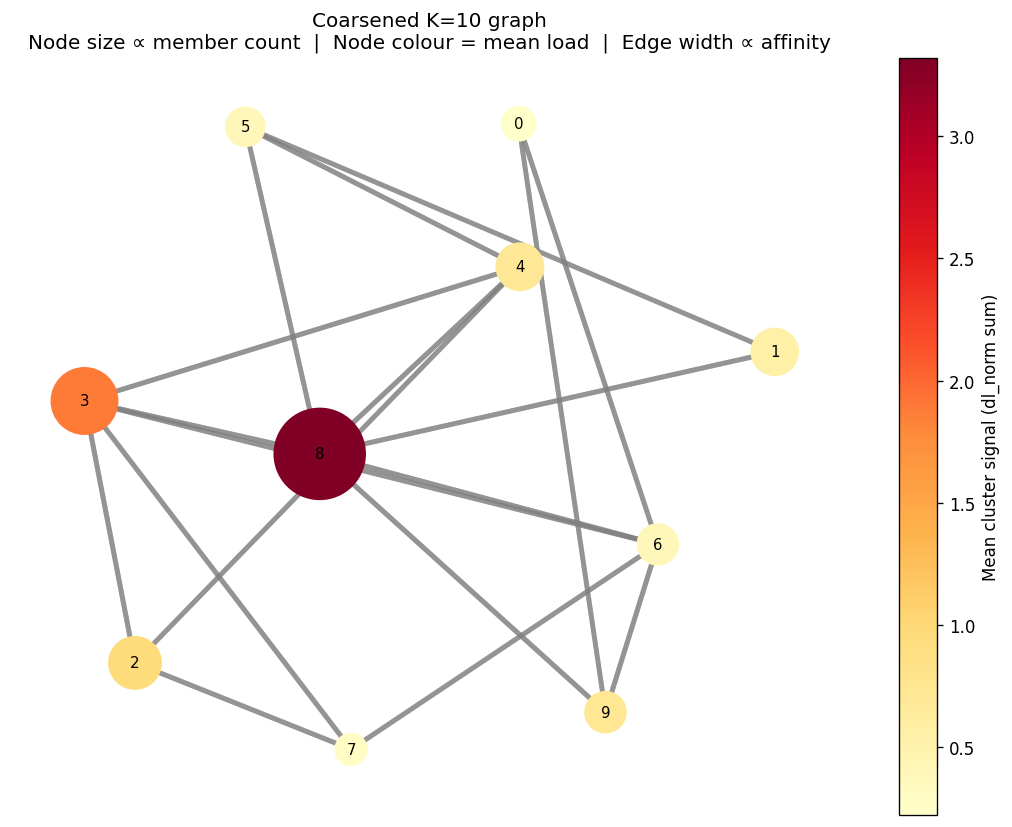

In [10]:
# Load coarse graph
coarse_ei = np.load(OUTPUT_DIR / 'coarse_edge_index.npy')   # (2, E_coarse)
coarse_ea = np.load(OUTPUT_DIR / 'coarse_edge_attr.npy')    # (E_coarse,)

# Build networkx graph (exclude self-loops for layout clarity)
G = nx.DiGraph()
G.add_nodes_from(range(K_INSPECT))
for (src, dst), w in zip(coarse_ei.T, coarse_ea):
    if src != dst:
        G.add_edge(int(src), int(dst), weight=float(w))

print(f'Coarse graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} directed edges')

# Node attributes for visualisation
node_sizes  = [summary_df.loc[k, 'n_members'] * 10 for k in range(K_INSPECT)]
node_colors = [summary_df.loc[k, 'mean_signal'] for k in range(K_INSPECT)]
edge_widths = [G[u][v]['weight'] * 3 for u, v in G.edges()]

pos = nx.spring_layout(G, seed=42, k=2.5)
fig, ax = plt.subplots(figsize=(9, 7))
nc = nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors,
                             cmap='YlOrRd', ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.6,
                        edge_color='grey', arrows=False, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)
plt.colorbar(nc, ax=ax, label='Mean cluster signal (dl_norm sum)')
ax.set_title(f'Coarsened K={K_INSPECT} graph\n'
             f'Node size ∝ member count  |  Node colour = mean load  |  Edge width ∝ affinity')
ax.axis('off')
plt.tight_layout()
plt.show()

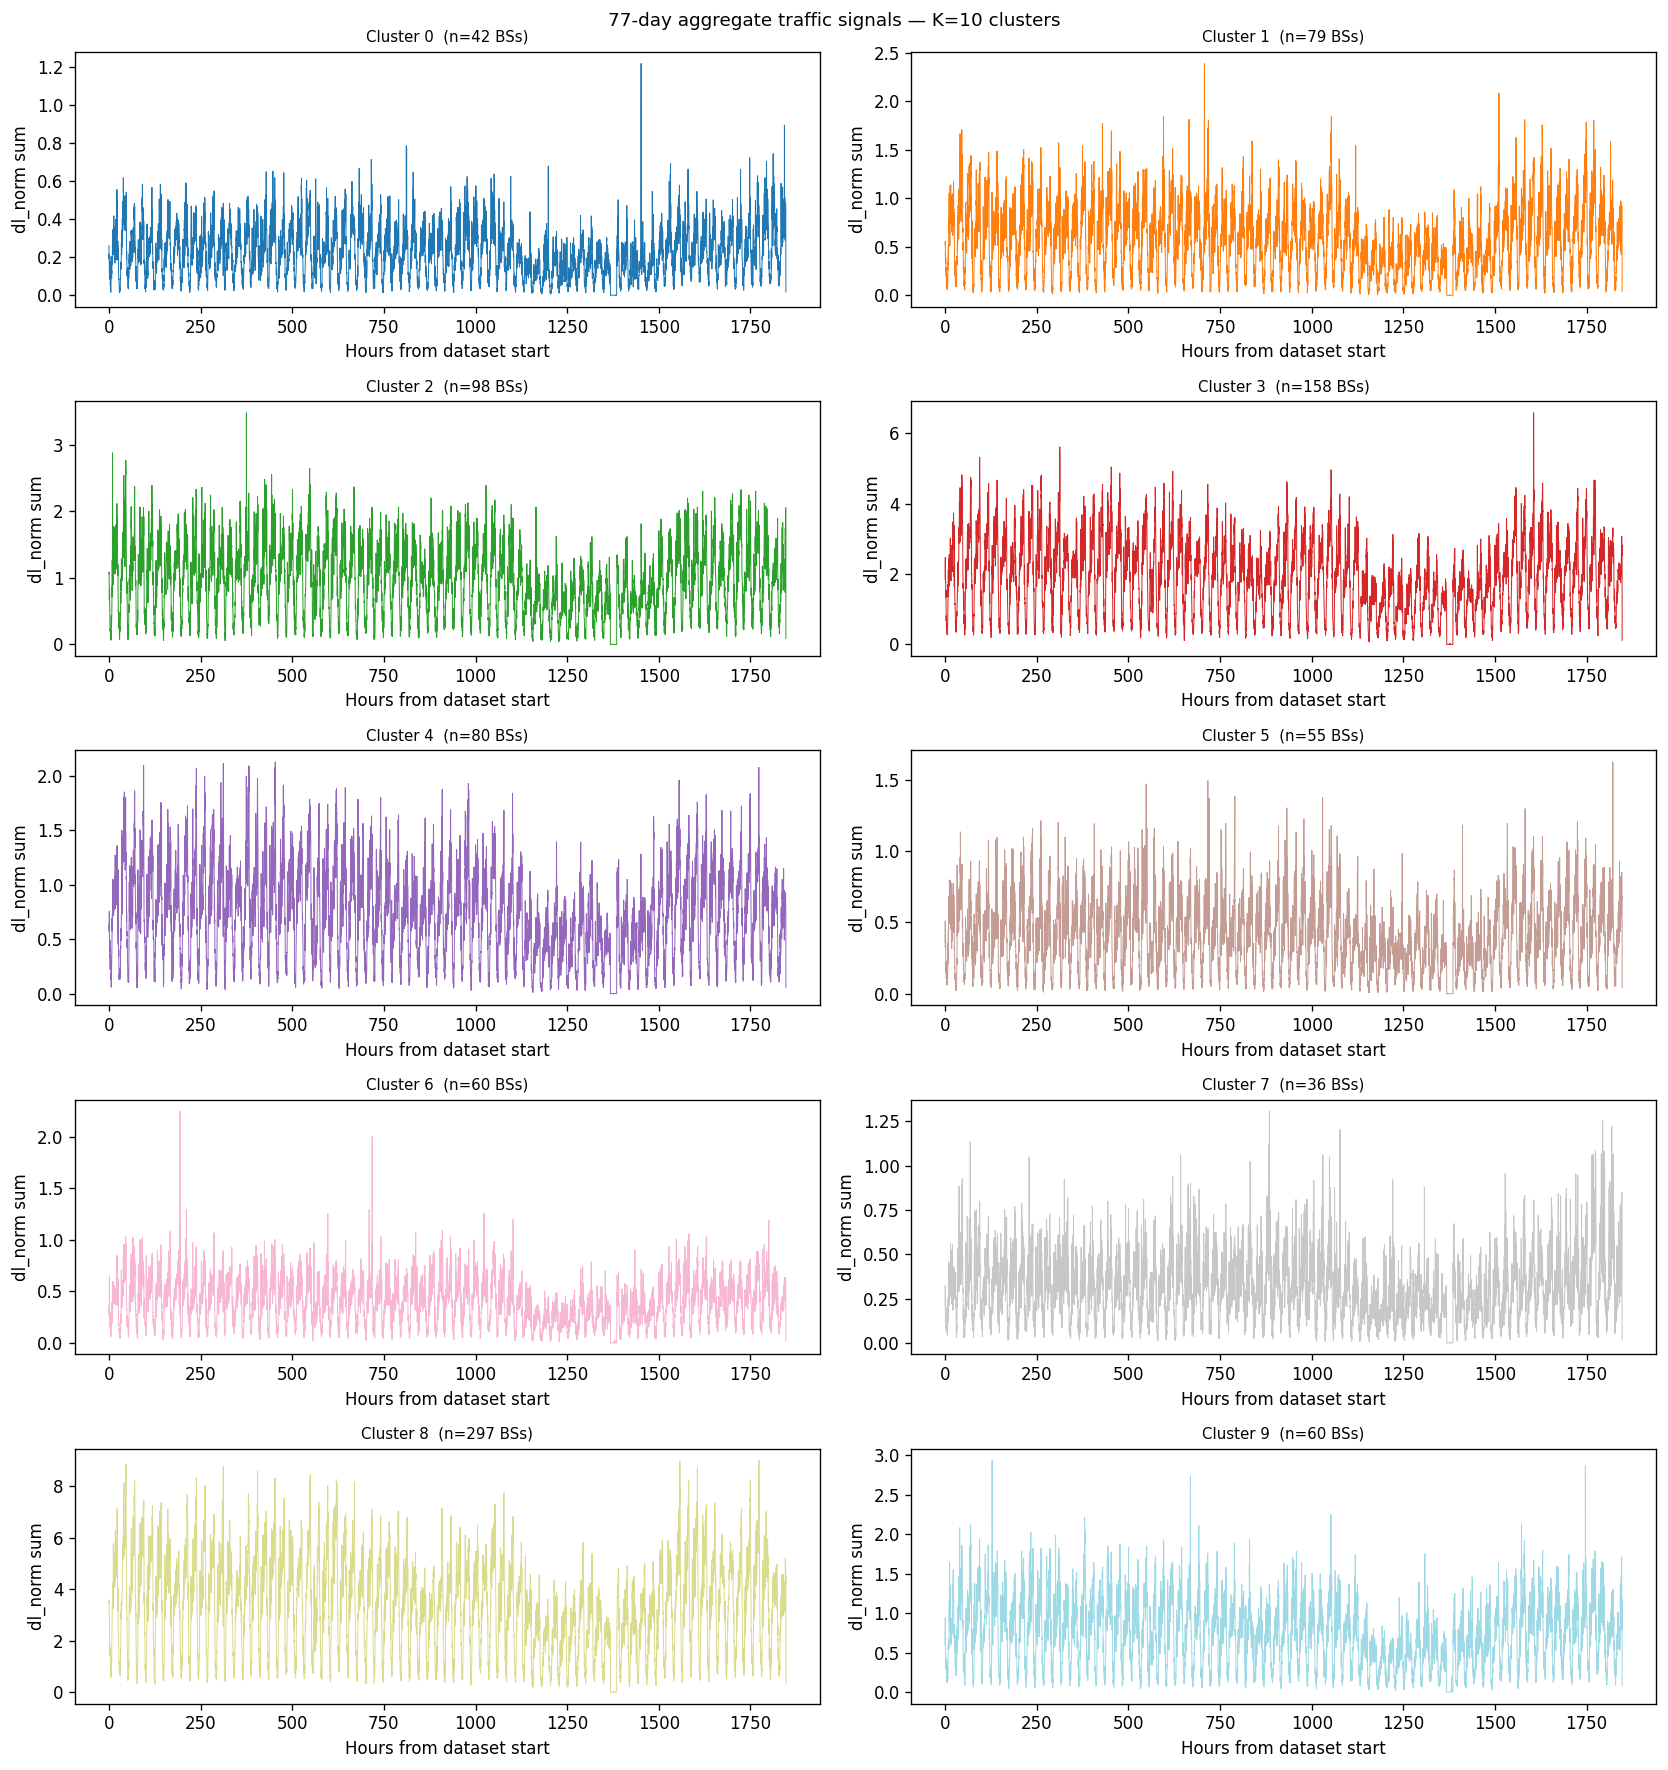

In [11]:
# ---- Cluster signals: 77-day aggregate traffic per cluster ----
T_total   = cluster_series.shape[1]
t_axis    = np.arange(T_total) * 15 / 60   # hours from start

n_cols = min(K_INSPECT, 2)
n_rows = (K_INSPECT + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows), squeeze=False)

for k in range(K_INSPECT):
    ax = axes[k // n_cols][k % n_cols]
    ax.plot(t_axis, cluster_series[k], linewidth=0.6, color=cmap(k))
    ax.set_title(f'Cluster {k}  (n={summary_df.loc[k, "n_members"]} BSs)', fontsize=9)
    ax.set_xlabel('Hours from dataset start')
    ax.set_ylabel('dl_norm sum')

for k in range(K_INSPECT, n_rows * n_cols):
    axes[k // n_cols][k % n_cols].set_visible(False)

fig.suptitle(f'77-day aggregate traffic signals — K={K_INSPECT} clusters', fontsize=11)
plt.tight_layout()
plt.show()

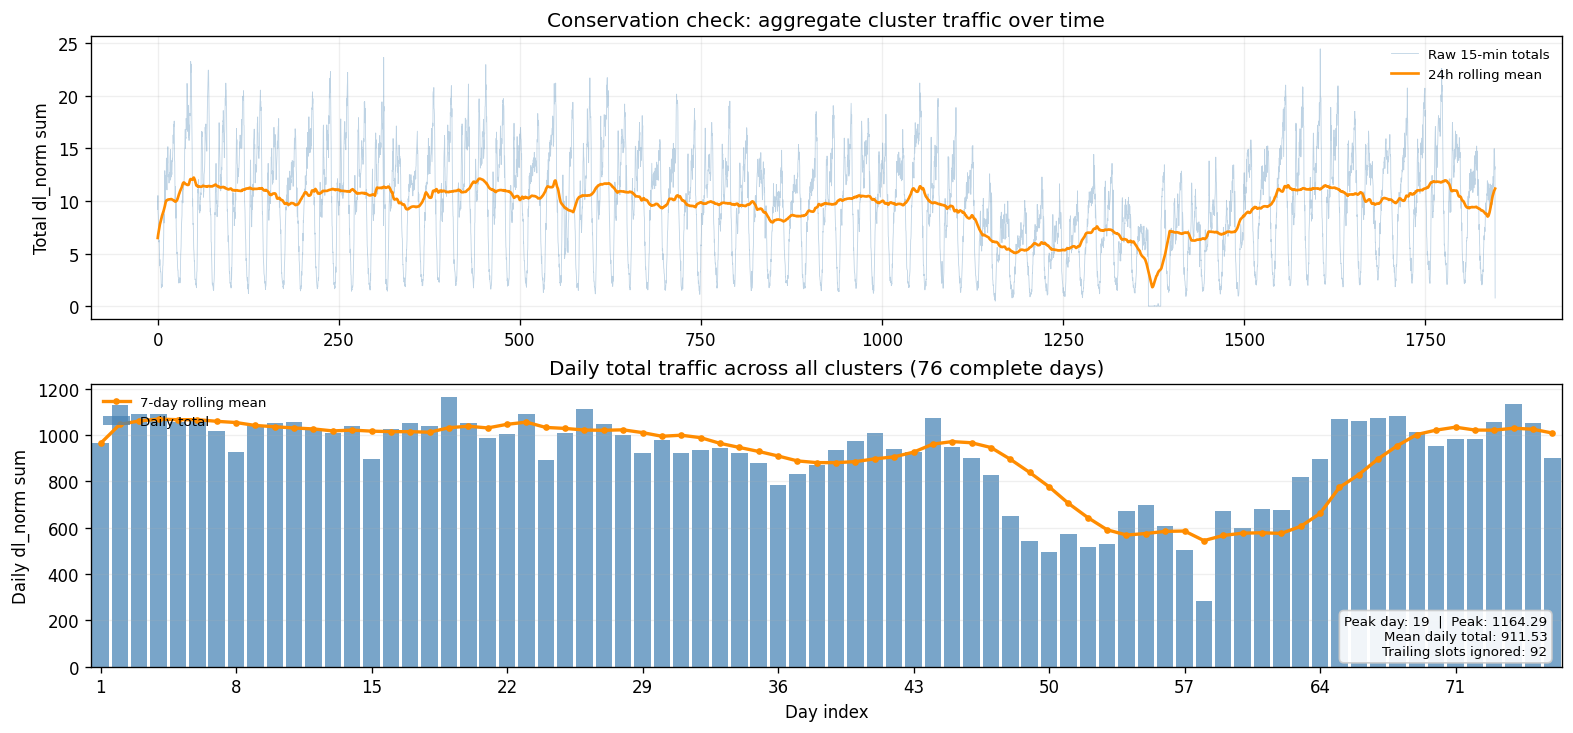

Max cluster signal value: 9.0114
Peak daily city total (sum of K clusters): 1164.29 on day 19
Mean daily city total: 911.53
Note: 92 trailing slots excluded from daily reshape


In [16]:
# ---- Conservation verification ----
# Sum of all cluster signals at each timestamp should equal sum of all BS signals.
# We also compress the full series into daily totals to make the weekly pattern easier to read.
cluster_totals = cluster_series.sum(axis=0)   # (T_total,)

raw_series = pd.Series(cluster_totals)
rolling_24h = raw_series.rolling(window=96, min_periods=1, center=True).mean()

# Only reshape complete days (drop trailing incomplete day if present)
n_complete_days = len(cluster_totals) // 96
daily_totals = cluster_totals[:n_complete_days * 96].reshape(-1, 96).sum(axis=1)   # sum per day
day_index = np.arange(1, n_complete_days + 1)
weekly_mean = pd.Series(daily_totals).rolling(window=7, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(13, 6), constrained_layout=True)

axes[0].plot(t_axis, cluster_totals, linewidth=0.5, color='steelblue', alpha=0.35, label='Raw 15-min totals')
axes[0].plot(t_axis, rolling_24h, linewidth=1.6, color='darkorange', label='24h rolling mean')
axes[0].set_title('Conservation check: aggregate cluster traffic over time')
axes[0].set_ylabel('Total dl_norm sum')
axes[0].grid(True, alpha=0.2)
axes[0].legend(loc='upper right', fontsize=8, frameon=False)

axes[1].bar(day_index, daily_totals, color='steelblue', alpha=0.72, width=0.85, label='Daily total')
axes[1].plot(day_index, weekly_mean, color='darkorange', linewidth=2, marker='o', markersize=3, label='7-day rolling mean')
axes[1].set_title(f'Daily total traffic across all clusters ({n_complete_days} complete days)')
axes[1].set_xlabel('Day index')
axes[1].set_ylabel('Daily dl_norm sum')
axes[1].set_xlim(0.5, n_complete_days + 0.5)
axes[1].set_xticks(np.arange(1, n_complete_days + 1, max(1, n_complete_days // 10)))
axes[1].grid(True, axis='y', alpha=0.2)
axes[1].legend(loc='upper left', fontsize=8, frameon=False)

peak_day = int(day_index[np.argmax(daily_totals)])
peak_value = float(np.max(daily_totals))
mean_value = float(np.mean(daily_totals))
axes[1].text(
    0.99, 0.03,
    f'Peak day: {peak_day}  |  Peak: {peak_value:.2f}\nMean daily total: {mean_value:.2f}\nTrailing slots ignored: {len(cluster_totals) % 96}',
    transform=axes[1].transAxes,
    ha='right', va='bottom', fontsize=8,
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='0.8', alpha=0.9),
)

plt.show()

print(f'Max cluster signal value: {cluster_series.max():.4f}')
print(f'Peak daily city total (sum of K clusters): {peak_value:.2f} on day {peak_day}')
print(f'Mean daily city total: {mean_value:.2f}')
print(f'Note: {len(cluster_totals) % 96} trailing slots excluded from daily reshape')

---
## Section 2 — Training Results

Loss curves for all K values in the sweep, and the sweep comparison table.

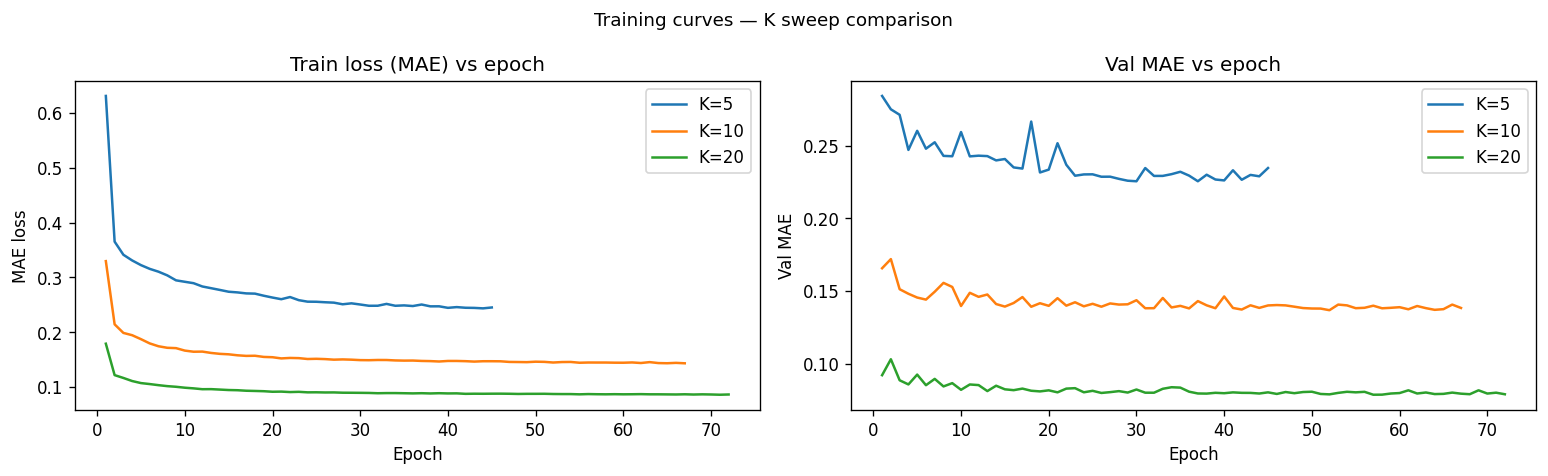

In [17]:
sweep_k = cfg['training']['sweep_k']
output_root = REPO_ROOT / cfg['paths']['output_dir']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for K_val in sweep_k:
    hist_path = output_root / f'K{K_val}' / 'training_history.json'
    if not hist_path.exists():
        print(f'  Skipping K={K_val} (no training_history.json)')
        continue
    with open(hist_path) as f:
        history = json.load(f)
    epochs    = [h['epoch']      for h in history]
    train_loss = [h['train_loss'] for h in history]
    val_mae    = [h['val_mae']    for h in history]
    axes[0].plot(epochs, train_loss, label=f'K={K_val}')
    axes[1].plot(epochs, val_mae,    label=f'K={K_val}')

axes[0].set_title('Train loss (MAE) vs epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MAE loss')
axes[0].legend()

axes[1].set_title('Val MAE vs epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val MAE')
axes[1].legend()

plt.suptitle('Training curves — K sweep comparison', fontsize=11)
plt.tight_layout()
plt.show()

In [18]:
# ---- K sweep comparison table ----
sweep_results_path = REPO_ROOT / cfg['paths']['results_dir'] / 'sweep_results.json'
if sweep_results_path.exists():
    with open(sweep_results_path) as f:
        sweep_results = json.load(f)
    sweep_df = pd.DataFrame(sweep_results).set_index('K')
    display(sweep_df.round(5))
else:
    print(f'sweep_results.json not found at {sweep_results_path}')
    print('Run src/train.py first.')

,val_MAE,val_RMSE,n_params,best_epoch,training_time_s
K,,,,,
5,0.22421,0.37201,60548,3,543.9


---
## Section 3 — Forecast Quality

Load test predictions (generated by evaluate.py), compare against baselines,
and examine the per-cluster error distribution.

In [19]:
# Load evaluate.py results for K_INSPECT
results_path = REPO_ROOT / cfg['paths']['results_dir'] / f'K{K_INSPECT}_results.json'
if not results_path.exists():
    print(f'Results not found: {results_path}')
    print(f'Run: python -m src.evaluate --n_clusters {K_INSPECT}')
else:
    with open(results_path) as f:
        results = json.load(f)

    metrics_table = []
    for method, mdict in [
        ('ClusterSTGNN', results['model']),
        ('Last-value',   results['last_value']),
        ('Hist-mean',    results['hist_mean']),
    ]:
        metrics_table.append({
            'Method': method,
            'MAE':    mdict['mae'],
            'RMSE':   mdict['rmse'],
            'MAPE':   mdict.get('mape', float('nan')),
        })
    display(pd.DataFrame(metrics_table).set_index('Method').round(5))

Results not found: ..\results\cluster_first\K10_results.json
Run: python -m src.evaluate --n_clusters 10


In [20]:
# ---- Re-run inference here for per-cluster plots ----
# (Avoids storing large prediction arrays in the JSON results)
import sys
sys.path.insert(0, str(REPO_ROOT))

from src.model import ClusterSTGNN
from src.cluster_dataset import ClusterTrafficDataset
from torch.utils.data import DataLoader

coarse_ei_t = torch.from_numpy(np.load(OUTPUT_DIR / 'coarse_edge_index.npy')).long()
coarse_ea_t = torch.from_numpy(np.load(OUTPUT_DIR / 'coarse_edge_attr.npy'))

seq_len = cfg['stgnn']['seq_len']
horizon = cfg['stgnn']['horizon']

test_ds = ClusterTrafficDataset(
    cluster_series=cluster_series,
    edge_index=coarse_ei_t,
    edge_attr=coarse_ea_t,
    seq_len=seq_len,
    horizon=horizon,
    split='test',
    val_split=cfg['training']['val_split'],
    test_split=cfg['training']['test_split'],
)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

ckpt  = torch.load(CKPT_DIR / 'best_model.pt', map_location='cpu')
model = ClusterSTGNN.from_config(cfg, n_clusters=K_INSPECT)
model.load_state_dict(ckpt['model_state'])
model.eval()

all_preds, all_trues = [], []
with torch.no_grad():
    for batch in test_loader:
        pred = model(batch['x'], batch['edge_index'][0], batch['edge_attr'][0])
        all_preds.append(pred)
        all_trues.append(batch['y'])

preds_np = torch.cat(all_preds).numpy()   # (n, horizon, K)
trues_np = torch.cat(all_trues).numpy()
print(f'preds_np: {preds_np.shape}  trues_np: {trues_np.shape}')

preds_np: (1009, 4, 10)  trues_np: (1009, 4, 10)


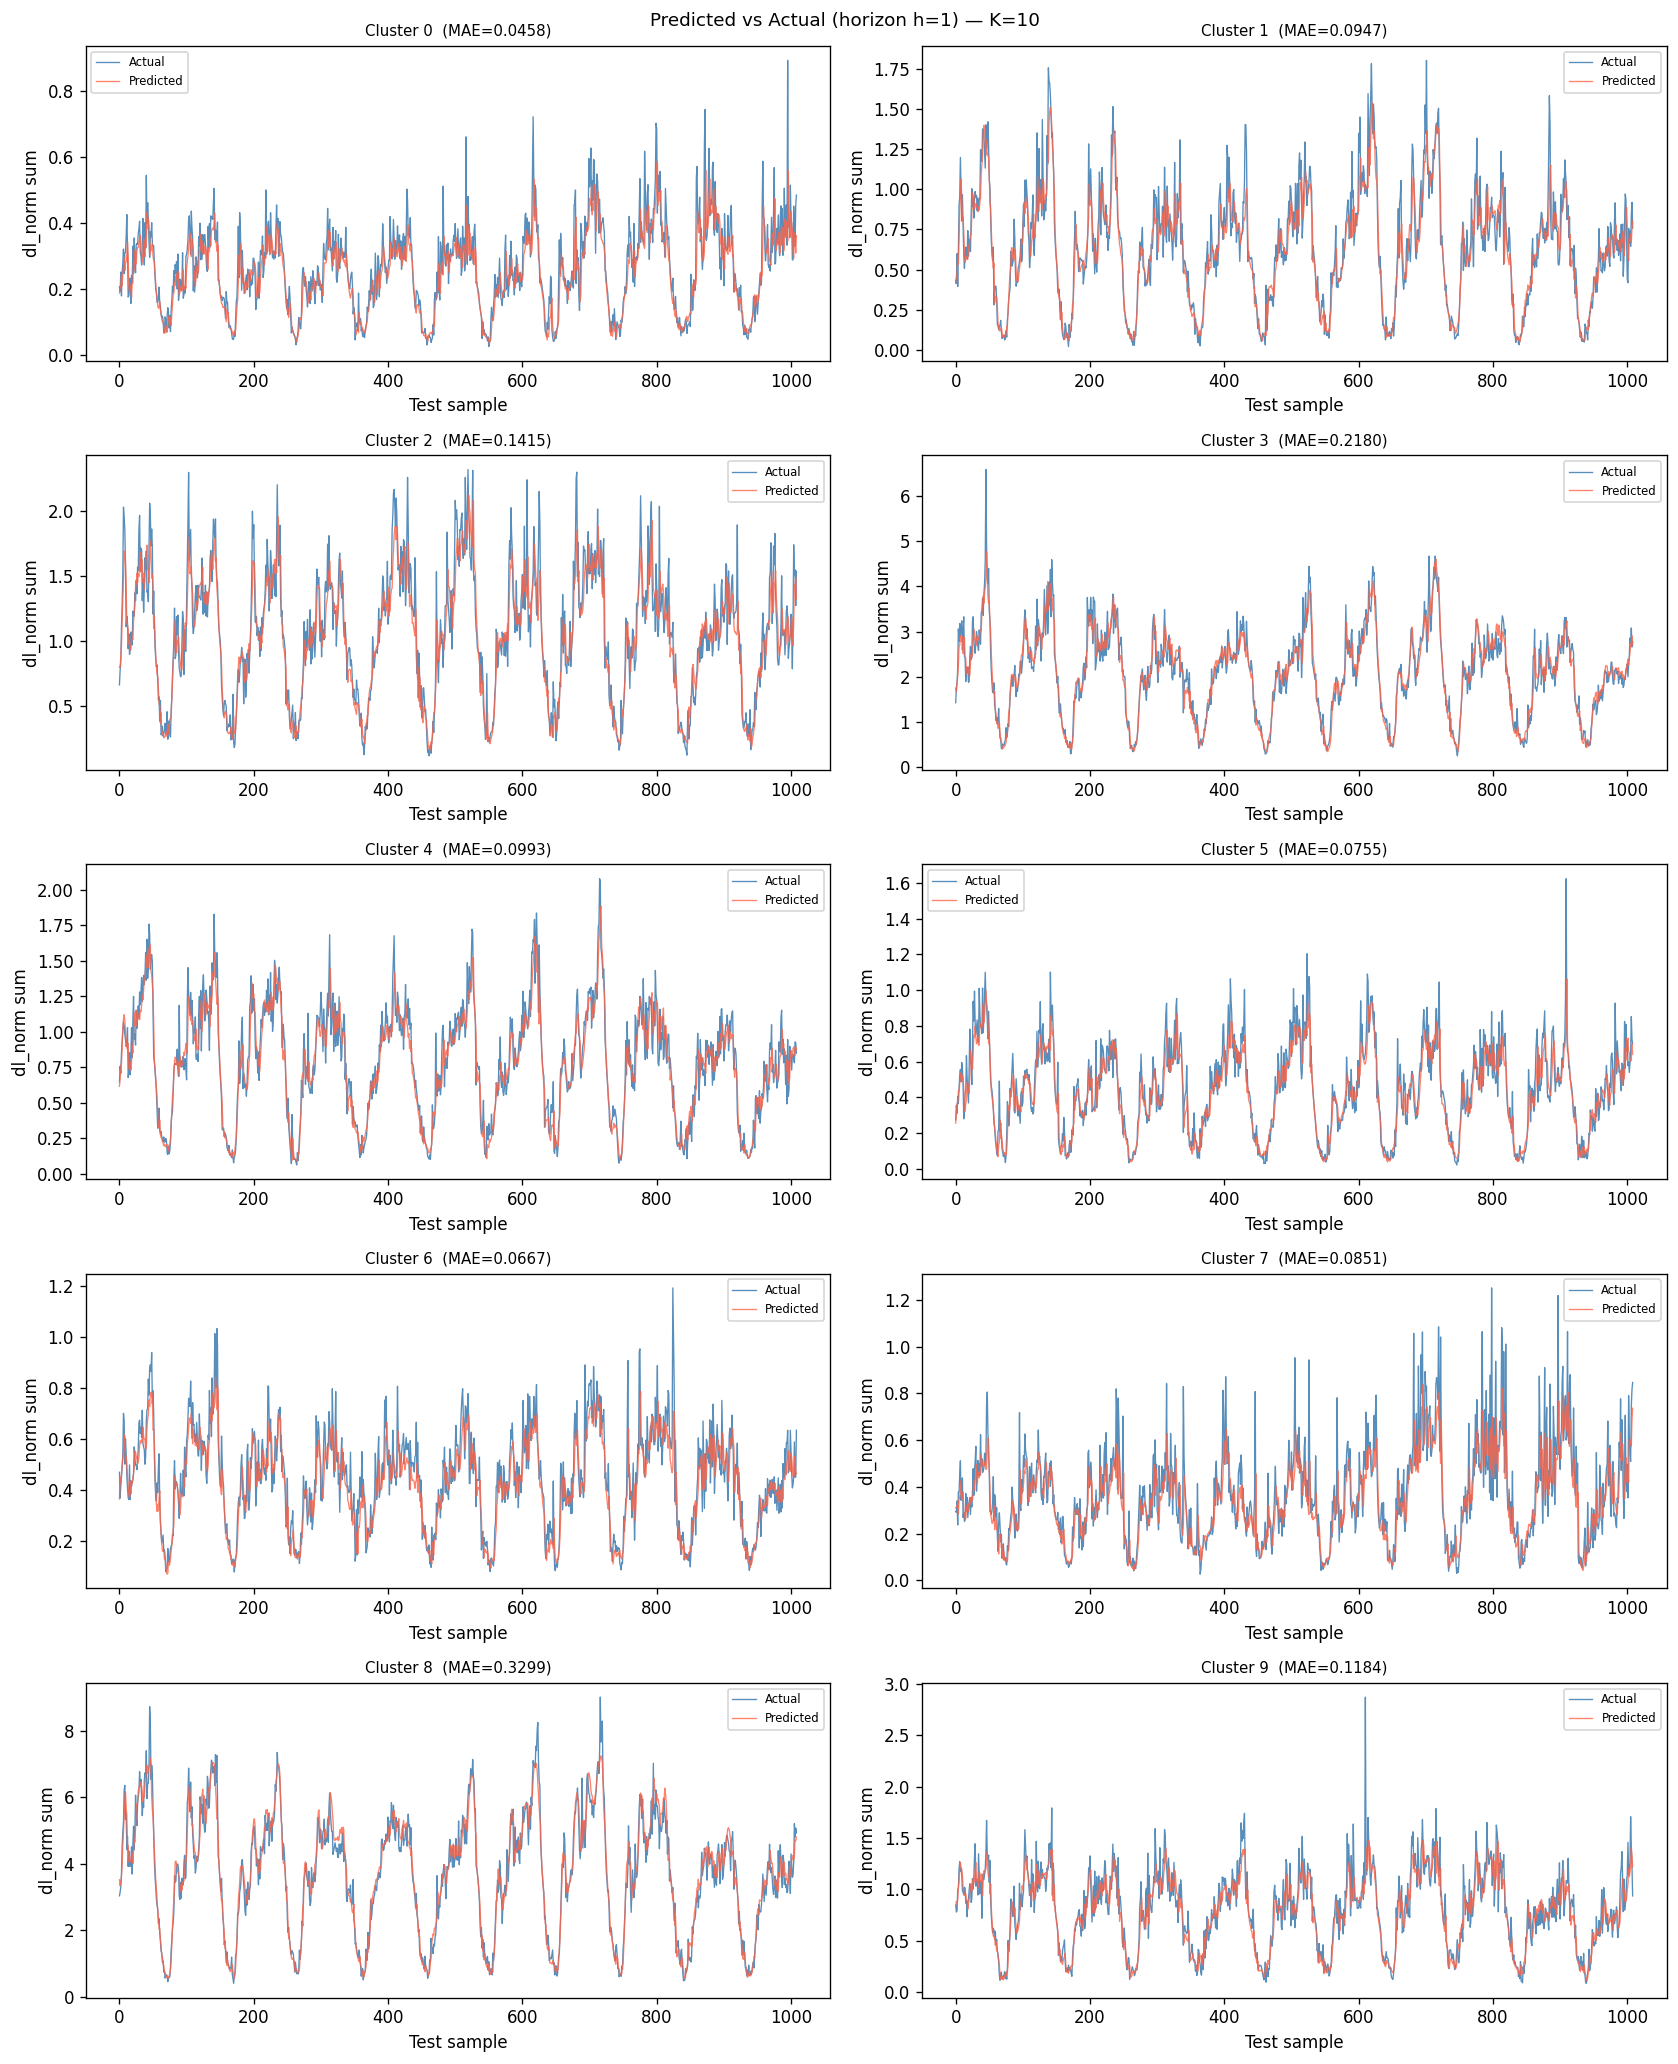

In [21]:
# ---- Predicted vs actual — horizon step 1 (15 min ahead) ----
n_cols = min(K_INSPECT, 2)
n_rows = (K_INSPECT + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows), squeeze=False)
for k in range(K_INSPECT):
    ax    = axes[k // n_cols][k % n_cols]
    p, t  = preds_np[:, 0, k], trues_np[:, 0, k]
    mae_k = float(np.mean(np.abs(p - t)))
    ax.plot(t, label='Actual',    color='steelblue', linewidth=0.8, alpha=0.9)
    ax.plot(p, label='Predicted', color='tomato',    linewidth=0.8, alpha=0.8)
    ax.set_title(f'Cluster {k}  (MAE={mae_k:.4f})', fontsize=9)
    ax.set_xlabel('Test sample')
    ax.set_ylabel('dl_norm sum')
    ax.legend(fontsize=7)

for k in range(K_INSPECT, n_rows * n_cols):
    axes[k // n_cols][k % n_cols].set_visible(False)

fig.suptitle(f'Predicted vs Actual (horizon h=1) — K={K_INSPECT}', fontsize=11)
plt.tight_layout()
plt.show()

C:\Users\Shima\AppData\Local\Temp\ipykernel_8632\2642352509.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


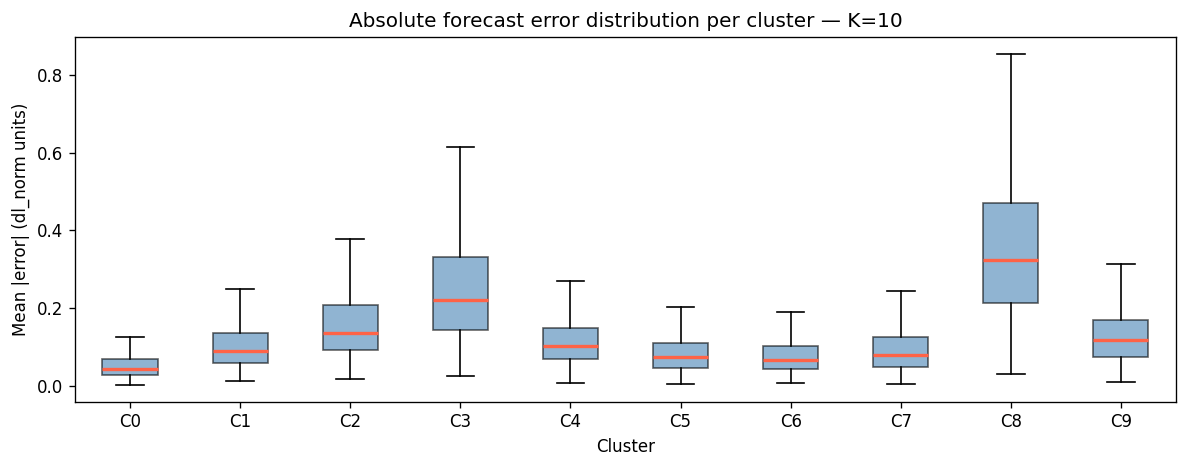

In [22]:
# ---- Error distribution per cluster (boxplot, all horizon steps) ----
abs_errors = np.abs(preds_np - trues_np)   # (n, horizon, K)
# Collapse horizon → (n, K)
abs_errors_flat = abs_errors.mean(axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot(
    [abs_errors_flat[:, k] for k in range(K_INSPECT)],
    labels=[f'C{k}' for k in range(K_INSPECT)],
    showfliers=False, patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='tomato', linewidth=2),
)
ax.set_title(f'Absolute forecast error distribution per cluster — K={K_INSPECT}')
ax.set_xlabel('Cluster')
ax.set_ylabel('Mean |error| (dl_norm units)')
plt.tight_layout()
plt.show()

---
## Section 4 — UPF Assignment Analysis

For mid-density α=0.200 Gbps/dl_norm-unit, we examine the UPF configuration
assignment over the test period and its energy consequences.

In [23]:
from src.evaluate import assign_upf, compute_energy

ALPHA = cfg['upf']['alpha_scenarios']['mid_density']   # 0.200
thresh_usr    = cfg['upf']['threshold_dpdk_gbps']      # 0.12
thresh_danger = cfg['upf']['threshold_danger_gbps']    # 0.17
dpdk_w        = cfg['upf']['energy_dpdk_w']
usr_slope     = cfg['upf']['energy_usr_slope']

lambda_pred  = preds_np * ALPHA   # (n, horizon, K)
lambda_true  = trues_np * ALPHA
types_model  = assign_upf(lambda_pred,  thresh_usr, thresh_danger)
types_oracle = assign_upf(lambda_true,  thresh_usr, thresh_danger)

acc = float(np.mean(types_model == types_oracle))
sla = float(np.mean(lambda_true >= thresh_danger))
print(f'α={ALPHA:.3f}  Assignment accuracy: {acc:.3f}  SLA violation rate: {sla:.4f}')

α=0.200  Assignment accuracy: 0.863  SLA violation rate: 0.3775


In [24]:
# ---- UPF assignment timeline: coloured bands per cluster ----
# Show horizon-step h=1 assignment over test samples
assignment_timeline = types_model[:, 0, :]   # (n_samples, K)

color_map = {'USR': 'forestgreen', 'DPDK': 'steelblue', 'DANGER': 'crimson'}
n_samples = assignment_timeline.shape[0]

fig, axes = plt.subplots(K_INSPECT, 1, figsize=(13, 1.5 * K_INSPECT), squeeze=False)
for k in range(K_INSPECT):
    ax = axes[k][0]
    colors_k = [color_map.get(t, 'grey') for t in assignment_timeline[:, k]]
    ax.bar(range(n_samples), np.ones(n_samples), color=colors_k, width=1.0, linewidth=0)
    ax.set_xlim(0, n_samples)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_ylabel(f'C{k}', rotation=0, labelpad=20, va='center')
    if k < K_INSPECT - 1:
        ax.set_xticks([])

axes[-1][0].set_xlabel('Test sample index')
patches = [mpatches.Patch(color=c, label=t) for t, c in color_map.items()]
fig.legend(handles=patches, loc='upper right', ncol=3)
fig.suptitle(f'UPF assignment timeline — K={K_INSPECT}, α={ALPHA:.3f}  '
             f'(green=USR, blue=DPDK, red=DANGER)', fontsize=10)
plt.tight_layout()
plt.show()

C:\Users\Shima\AppData\Local\Temp\ipykernel_8632\1478881612.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [25]:
# ---- Energy comparison across methods ----
alphas      = list(cfg['upf']['alpha_scenarios'].values())
alpha_names = list(cfg['upf']['alpha_scenarios'].keys())

methods = ['Model', 'Oracle', 'All-DPDK', 'All-USR']
energy_table = []

for alpha, name in zip(alphas, alpha_names):
    lp = preds_np * alpha
    lt = trues_np * alpha
    tp = assign_upf(lp, thresh_usr, thresh_danger)
    to = assign_upf(lt, thresh_usr, thresh_danger)

    e_model  = float(compute_energy(lp, tp, usr_slope, dpdk_w).sum(axis=-1).mean())
    e_oracle = float(compute_energy(lt, to, usr_slope, dpdk_w).sum(axis=-1).mean())
    e_dpdk   = float(np.full_like(lt, dpdk_w).sum(axis=-1).mean())
    e_usr    = float((usr_slope * lt).sum(axis=-1).mean())

    energy_table.append({
        'scenario': name, 'alpha': alpha,
        'Model_W': e_model, 'Oracle_W': e_oracle,
        'All-DPDK_W': e_dpdk, 'All-USR_W': e_usr,
        'savings_vs_DPDK_%': round((e_dpdk - e_model) / e_dpdk * 100, 1),
    })

energy_df = pd.DataFrame(energy_table).set_index('scenario')
display(energy_df.round(3))

,alpha,Model_W,Oracle_W,All-DPDK_W,All-USR_W,savings_vs_DPDK_%
scenario,,,,,,
low_density,0.1,4.606,4.705,8.2,7.242,43.8
mid_density,0.2,6.350,6.428,8.2,14.484,22.6
high_density,0.5,7.720,7.712,8.2,36.211,5.9


In [26]:
# ---- Energy bar chart ----
x   = np.arange(len(alphas))
w   = 0.20
fig, ax = plt.subplots(figsize=(9, 4))

colors = ['tomato', 'gold', 'steelblue', 'forestgreen']
for i, (method_col, mc) in enumerate(zip(
    ['Model_W', 'Oracle_W', 'All-DPDK_W', 'All-USR_W'], colors
)):
    vals = energy_df[method_col].values
    ax.bar(x + (i - 1.5) * w, vals, width=w, label=method_col.replace('_W',''), color=mc, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'{n}\n(α={a:.3f})' for n, a in zip(alpha_names, alphas)])
ax.set_ylabel('Mean total UPF energy (W)')
ax.set_title(f'Energy comparison across methods and α scenarios — K={K_INSPECT}')
ax.legend()
plt.tight_layout()
plt.show()

C:\Users\Shima\AppData\Local\Temp\ipykernel_8632\221733178.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


---
## Section 5 — Comparison with Original BS-Level STGNN

The two architectures solve different tasks, so direct MAE comparison is
informative but **not apples-to-apples**:

| | Original STGNN | Cluster-first STGNN |
|---|---|---|
| What is predicted | per-BS dl_norm (0–1) | cluster aggregate dl_norm sum |
| Nodes | 965 | K (5–20) |
| Optimisation target | per-BS MAE | cluster-level MAE |
| UPF relevance | indirect (aggregate after training) | direct |

When we aggregate the original STGNN's 965-node forecasts to cluster level,
the errors partially cancel out (aggregation smoothing).  The cluster-first
model directly minimises what matters for UPF decisions.

In [27]:
# ---- Computational comparison ----
from src.model import ClusterSTGNN

cluster_model = ClusterSTGNN.from_config(cfg, n_clusters=K_INSPECT)
cluster_params = cluster_model.count_parameters()

# Original STGNN params (from CLAUDE.md)
original_params = 73284

comp_data = [
    {'Model': f'ClusterSTGNN (K={K_INSPECT})',
     'n_params':       cluster_params,
     'n_nodes':        K_INSPECT,
     'optimises':      'cluster-level MAE',
     'upf_relevance':  'direct'},
    {'Model': 'Original TrafficSTGNN',
     'n_params':       original_params,
     'n_nodes':        965,
     'optimises':      'per-BS MAE',
     'upf_relevance':  'indirect (post-hoc aggregation)'},
]
display(pd.DataFrame(comp_data).set_index('Model'))

,n_params,n_nodes,optimises,upf_relevance
Model,,,,
ClusterSTGNN (K=10),60548,10,cluster-level MAE,direct
Original TrafficSTGNN,73284,965,per-BS MAE,indirect (post-hoc aggregation)


In [28]:
# ---- Cluster-level MAE: ClusterSTGNN vs aggregated original ----
# This cell shows how the cluster-first model's cluster MAE compares to what
# the original STGNN would produce if its per-BS predictions were aggregated.
#
# NOTE: For a fair comparison, the original STGNN predictions need to be
# available. If the original checkpoint is present, load it and run inference.
# Otherwise, we report the cluster-first numbers and note the comparison.

cluster_mae = float(np.mean(np.abs(preds_np - trues_np)))
print(f'ClusterSTGNN (K={K_INSPECT}) cluster-level MAE: {cluster_mae:.5f}')
print()
print('Interpretation notes:')
print('  - This MAE is on cluster aggregate signals (sum of K BSs), not individual BSs.')
print('  - Larger signals have larger absolute errors; per-unit error stays similar.')
print('  - Aggregation smoothing means any model\'s cluster-level MAE is lower')
print('    than its per-BS MAE summed — the comparison is informative but not direct.')
print('  - The key advantage of cluster-first is architectural alignment:')
print('    the model is trained to minimise exactly the error that affects')
print('    UPF threshold decisions, not a surrogate per-node objective.')

# Cluster-level per-K MAE table
per_cluster = {f'C{k}': float(np.mean(np.abs(preds_np[:,:,k] - trues_np[:,:,k])))
               for k in range(K_INSPECT)}
display(pd.Series(per_cluster, name='cluster_MAE').to_frame())

ClusterSTGNN (K=10) cluster-level MAE: 0.14450

Interpretation notes:
  - This MAE is on cluster aggregate signals (sum of K BSs), not individual BSs.
  - Larger signals have larger absolute errors; per-unit error stays similar.
  - Aggregation smoothing means any model's cluster-level MAE is lower
    than its per-BS MAE summed — the comparison is informative but not direct.
  - The key advantage of cluster-first is architectural alignment:
    the model is trained to minimise exactly the error that affects
    UPF threshold decisions, not a surrogate per-node objective.


,cluster_MAE
C0,0.052546
C1,0.107836
C2,0.163578
C3,0.255079
C4,0.113026
C5,0.086129
C6,0.077802
C7,0.094096
C8,0.364462
C9,0.130493


In [30]:
# ---- Per-horizon error (h=1 to h=4) ----
fig, ax = plt.subplots(figsize=(7, 4))
horizon_maes = [
    float(np.mean(np.abs(preds_np[:, h, :] - trues_np[:, h, :])))
    for h in range(preds_np.shape[1])
]
ax.plot(range(1, len(horizon_maes)+1), horizon_maes, marker='o', color='steelblue')
ax.set_xticks(range(1, len(horizon_maes)+1))
ax.set_xticklabels([f'h={h+1}\n({(h+1)*15} min)' for h in range(len(horizon_maes))])
ax.set_ylabel('Mean Absolute Error (dl_norm units)')
ax.set_title(f'Forecast error vs horizon — K={K_INSPECT}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nPipeline summary:')
print(f'  K={K_INSPECT} clusters, seq_len={seq_len}, horizon={horizon}')
print(f'  ClusterSTGNN params: {cluster_params:,}')
print(f'  Cluster-level test MAE: {cluster_mae:.5f}')
print(f'  Best energy savings vs all-DPDK (mid-density): '
      f"{energy_df.loc['mid_density', 'savings_vs_DPDK_%']:.1f}%")


Pipeline summary:
  K=10 clusters, seq_len=96, horizon=4
  ClusterSTGNN params: 60,548
  Cluster-level test MAE: 0.14450
  Best energy savings vs all-DPDK (mid-density): 22.6%


C:\Users\Shima\AppData\Local\Temp\ipykernel_8632\1079768327.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
